# Task Comparison: PSDs and Topomaps

## Overview

You will convert task markers into 15-second epochs, compare condition spectra, and map alpha power. The cells provide structure and API hints, but you must implement the analysis and check each intermediate result.

## Learning objectives

- Standardize task-marker variants without changing their timing.
- Convert annotations into events and exact 15-second epochs.
- Compute and compare Welch PSDs.
- Summarize 8–12 Hz alpha activity for each EEG channel.
- Make comparable condition and difference topomaps.

## Scientific background: eyes-closed alpha

Alpha is an approximately 8–12 Hz rhythm often strongest over posterior scalp during quiet wakefulness. Closing the eyes commonly increases posterior alpha power. This is an expected tendency, not a guaranteed individual result. Drowsiness, muscle artifacts, reference choice, marker errors, and electrode layout can alter the pattern.

In [1]:
# Setup cell: run this as provided.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pyxdf
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.eeg_utils import extract_marker_annotations, summarize_xdf_streams

mne.set_log_level("WARNING")

## Step 1: Load preprocessed EEG

Load the FIF file with preload enabled. Print duration, sampling rate, EEG channel count, bad channels, and annotation count. Confirm that these values agree with earlier notebooks before analyzing conditions.

In [2]:
PREPROCESSED_PATH = Path("../outputs/motor_preprocessed.fif")

# TODO: load the preprocessed Raw object into memory.
raw = mne.io.read_raw_fif(PREPROCESSED_PATH, preload=True)

# TODO: print the requested quality-control information
print(raw.duration)
len(raw.info['ch_names'])
raw.info['bads']
mne.count_annotations(raw.annotations)


C:\Users\evana\AppData\Local\Temp\ipykernel_25120\3224513413.py:4: RuntimeWarning: This filename (..\outputs\motor_preprocessed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(PREPROCESSED_PATH, preload=True)


941.0166666666667


{'left_hand': 60, 'right_hand': 60}

## Step 2: Load or recreate task annotations

First inspect `raw.annotations.description` with `value_counts`. If task markers were saved in Notebook 1, use them. If not, reload the original XDF, display its stream summary, select EEG and marker indices, and call `extract_marker_annotations(marker_stream, raw_start_time=first_eeg_timestamp)`.

Marker spelling often varies. The accepted variants below are deliberately editable. Normalize strings only for matching; do not change timestamps. Build new annotations whose descriptions are exactly `eyes_open` or `eyes_closed`, with 15-second durations. Preserve annotations beginning with `BAD` or `EDGE` so MNE can reject affected epochs.

## Step 3: Convert annotations to events

Set the canonical annotations on a copy of `raw`. Define explicit codes `eyes_open: 1` and `eyes_closed: 2`, then use `mne.events_from_annotations`. Count both event codes. The expected design has 20 per condition; do not silently continue if counts differ. Investigate missing, extra, or misspelled markers.

In [3]:
# TODO: attach canonical task annotations (and quality annotations if present).



# TODO: convert annotations to events using the explicit event_id.
events, returned_event_id = mne.events_from_annotations(raw)

# TODO: count events for each condition and compare with 20 each.
event_counts = mne.count_events(events)
print(event_counts)
events
returned_event_id

{1: 60, 2: 60}


{np.str_('left_hand'): 1, np.str_('right_hand'): 2}

## Step 4: Create eyes-open and eyes-closed epochs

Create epochs beginning at each marker. To obtain exactly 15 seconds of samples, use `tmin=0` and `tmax=15 - 1/sfreq`. Set `baseline=None`, select EEG channels, preload, and reject segments overlapped by BAD annotations. Print retained counts and inspect `epochs.drop_log`.

In [72]:
TRIAL_DURATION = 5.0

# TODO: calculate an inclusive MNE tmax for exactly 15 seconds.
tmax = 5 - 1/raw.info['sfreq']

# TODO: create the epochs with the parameters described above.
epochs = mne.Epochs(
    raw=raw,
    events=events,
    event_id=returned_event_id,
    tmin=-1,
    tmax=5,
    baseline=(-1,0),
    picks='eeg',
    preload=True,
    reject_by_annotation='bads',
)

# TODO: print retained counts for both conditions.
epochs.drop_log
len(epochs)
epochs.crop(tmin=1,tmax=4)
epochs.times[0]
epochs.drop_channels(['F8','Fp1','F4','F7','Fp2'])

<Epochs | 120 events (all good), 1 – 4 s (baseline -1 – 0 s (baseline period was cropped after baseline correction)), ~11.6 MiB, data loaded,
 np.str_('left_hand'): 60
 np.str_('right_hand'): 60>

## Step 5: Plot example epochs

Plot three eyes-open and three eyes-closed epochs using MNE condition selection (`epochs['condition']`). Inspect whether one large artifact could dominate a condition average. Record any trial exclusions using a rule that does not depend on condition.

In [69]:
# TODO: select and plot up to three epochs from each condition.
epochs['right_hand'][:3].plot()
epochs['left_hand'][:3].plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x21ef8eabf20) at 0x0000021E82EB2780>

## Step 6: Compare PSDs

MNE can calculate and plot the power spectral density (PSD) for us. Use `epochs[condition].compute_psd(method='welch', fmin=1, fmax=40)` for each condition, then call the spectrum's `.plot(average=True)` method. MNE handles the Welch settings, averaging, units, and display scaling.

Make two plots side by side with a shared y-axis. Look for a larger bump near 8–12 Hz in the eyes-closed plot. Keeping the same frequency range and shared y-axis makes the comparison fair.

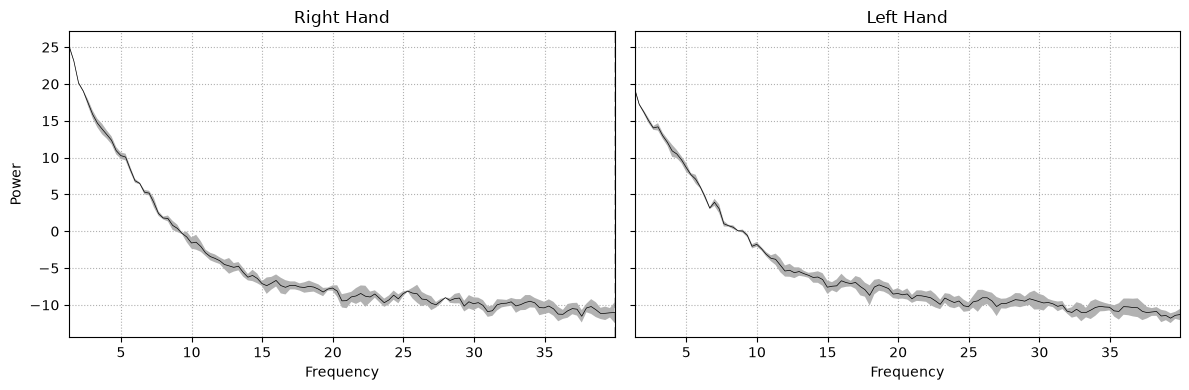

In [73]:
# TODO: compute a 1–40 Hz spectrum for each condition.
psd_right = epochs['right_hand'].compute_psd(method="welch", fmin=1, fmax=40)
psd_left = epochs['left_hand'].compute_psd(method="welch", fmin=1, fmax=40)

# TODO: let MNE plot the average EEG spectrum for each condition.
MC = ['C3','C4','Cz']
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
psd_right.plot(average=True, picks=MC, axes=axes[0], show=False)
psd_left.plot(average=True, picks=MC, axes=axes[1], show=False)
axes[0].set_title("Right Hand")
axes[0].set_xlabel('Frequency')
axes[1].set_xlabel('Frequency')
axes[1].set_title("Left Hand")
axes[0].set_ylabel('Power')
plt.tight_layout()


In [49]:
raw.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x21eed8f7440) at 0x0000021E81AB0CC0>

## Step 7: Compute alpha-band power

A PSD contains many frequency values for every channel. A topomap needs just **one number per channel**, so we need a simple alpha summary.

Compute a second spectrum restricted to 8–12 Hz. `get_data()` has the shape trials × channels × frequencies. Taking the mean across trials (axis 0) and frequencies (axis 2) leaves one mean alpha PSD value per channel. Multiplying by `1e12` converts V²/Hz to the more readable µV²/Hz.

This tutorial uses the mean PSD within the alpha range. Integrating the curve would estimate total alpha-band power, but that additional numerical concept is not needed to compare conditions here.

In [86]:
# TODO: compute spectra containing only the 8–12 Hz alpha range.
beta_psd_right = epochs['right_hand'].compute_psd(method="welch", fmin=8, fmax=13)
beta_psd_left = epochs['left_hand'].compute_psd(method="welch", fmin=8, fmax=13)

# TODO: average over trials and frequency bins, leaving one value per channel.
# The factor 1e12 converts V²/Hz to µV²/Hz.
beta_right_mean = beta_psd_right.get_data().mean(axis=(0, 2)) * 1e12
beta_left_mean = beta_psd_left.get_data().mean(axis=(0, 2)) * 1e12
beta_difference = beta_right_mean - beta_left_mean

# TODO: display a channel table to see where the largest differences occur.
beta_table = pd.DataFrame(
    {"right_hand": beta_right_mean, "left_hand": beta_left_mean, "right_minus_left": beta_difference},
    index=epochs.ch_names,
)
display(beta_table.sort_values("right_minus_left", ascending=False))

,right_hand,left_hand,right_minus_left
T6,1.334502,0.997466,0.337036
Pz,1.345949,1.067001,0.278948
P4,1.191870,0.928744,0.263127
T5,1.208557,0.946827,0.261730
T4,1.109876,0.862133,0.247743
P3,0.934756,0.743371,0.191385
C4,0.774059,0.602600,0.171459
Cz,0.683699,0.544175,0.139525
Fz,0.371303,0.297378,0.073925
F3,0.448310,0.383205,0.065105


In [87]:
print(beta_table['right_hand']['C4'] - beta_table['right_hand']['C3'])
print(beta_table['left_hand']['C4'] - beta_table['left_hand']['C3'])

0.1312282696819591
-0.004449053624609123


## Step 8: Plot alpha topomaps

Topomaps need electrode locations. Instead of inspecting coordinate arrays, first call `epochs.plot_sensors(show_names=True)`. You should see the channel names arranged sensibly around a head. If MNE reports missing locations—or channels appear piled together—return to Notebook 2 and set the correct montage.

Once the sensor plot looks correct, use the spectrum object's built-in `.plot_topomap()` method. Pass an alpha band dictionary such as `{'Alpha (8–12 Hz)': (8, 12)}`. MNE will average the alpha frequencies and draw the scalp map. Make one map for each condition and read each colorbar before comparing colors.

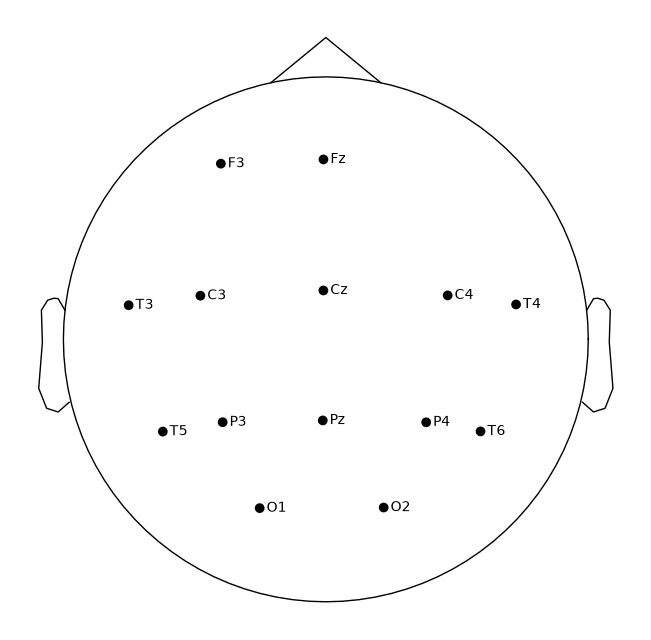

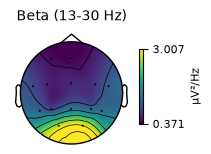

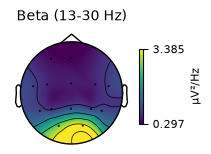

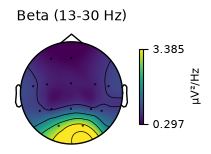

In [75]:
# Visual check: do the labels appear in sensible locations on the head?
epochs.plot_sensors(show_names=True)

beta_band = {"Beta (13-30 Hz)": (8, 13)}

# TODO: use MNE's built-in topomap method for each alpha spectrum.
beta_psd_right.plot_topomap(
    bands= beta_band, ch_type="eeg", cmap="viridis"
)
beta_psd_left.plot_topomap(
    bands= beta_band, ch_type="eeg", cmap="viridis"
)

## Step 9: Plot eyes-closed minus eyes-open alpha difference

The two condition maps may use different automatic color scales, so the clearest direct comparison is a difference map. Subtract eyes-open from eyes-closed mean alpha PSD for every channel.

Use `mne.viz.plot_topomap` with a red–blue color map. Set equal negative and positive limits using the largest absolute difference so zero is the center: red indicates stronger eyes-closed alpha and blue indicates stronger eyes-open alpha. A posterior red region supports the hypothesis descriptively; it is not a statistical significance test.

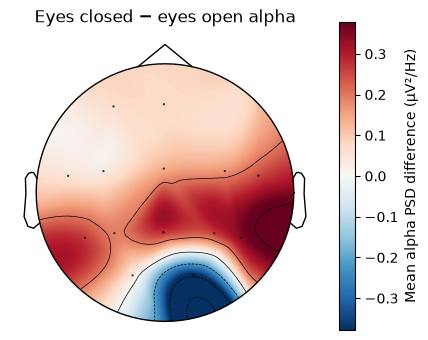

In [76]:
# TODO: center the color scale on zero using the largest absolute difference.
difference_limit = np.abs(beta_difference).max()
fig, ax = plt.subplots(figsize=(5, 4))
image, _ = mne.viz.plot_topomap(
    beta_difference, epochs.info, axes=ax, cmap='RdBu_r',
    vlim=(-difference_limit,difference_limit), show=False)
ax.set_title("Eyes closed − eyes open alpha")
fig.colorbar(image, ax=ax, label="Mean alpha PSD difference (µV²/Hz)")

# TODO: save the epochs for Notebook 4.
#EPOCHS_PATH = Path("../outputs/eyes_open_closed_epo.fif")
#raw.save(EPOCHS_PATH, overwrite=True)

## Student exercises

1. Compare a posterior-channel PSD with a frontal-channel PSD.
2. Repeat the alpha summary with 8–13 Hz and document whether the conclusion changes.
3. Plot trial-level alpha values for the strongest-difference channel and identify outliers without deleting them.

    Condition  Trial      Value
0   eyes_open     14  18.154150
1  eye_closed      5   0.523244


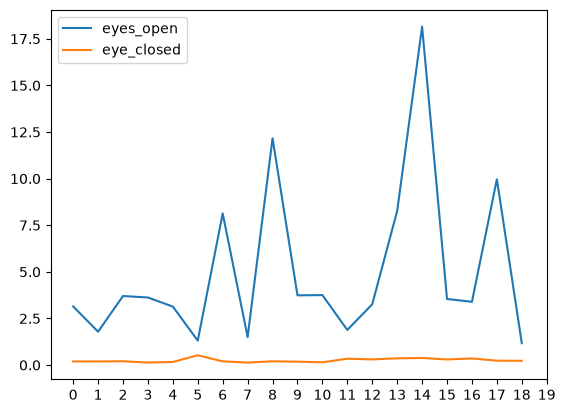

In [100]:
max_diff_channel = abs(alpha_table['closed_minus_open']).idxmax()
alpha_open_trials = alpha_psd_open.get_data().mean(axis=2) * 1e12
alpha_closed_trials = alpha_psd_closed.get_data().mean(axis=2) * 1e12
open_dataframe = pd.DataFrame(alpha_open_trials, index=epochs.ch_names)
closed_dataframe = pd.DataFrame(alpha_closed_trials, index=epochs.ch_names)
OpenO2 = open_dataframe.loc[max_diff_channel].values.tolist()
ClosedO2 = closed_dataframe.loc[max_diff_channel].values.tolist()
O2trials = pd.DataFrame({'eyes_open': OpenO2, 'eye_closed': ClosedO2})
O2trials.plot(xticks=range(0,20))


outlier_list = []

for column in O2trials.columns:
    mean = O2trials[column].mean()
    std = O2trials[column].std()

    mask = abs(O2trials[column] - mean) > 2 * std

    for idx, value in O2trials.loc[mask, column].items():
        outlier_list.append({
            "Condition": column,
            "Trial": idx,
            "Value": value
        })

outliers_df = pd.DataFrame(outlier_list)

print(outliers_df)

## Reflection questions

- Why might eyes-closed trials increase alpha power?
- Which channels showed the strongest difference? Were they posterior?
- Did a few trials dominate the average?
- What timing or label error could create a misleading condition difference?

## Summary

After completing the TODOs, you will have built condition epochs from real markers, checked trial counts, used MNE's built-in PSD plots, summarized alpha activity, and created condition and difference scalp maps.